For LBM, we need to split our 1D domain into a number of lattice sites (grid points)

So we have positions:

\begin{equation}
    x=0,1,2,...,N-1
\end{equation}

In [24]:
import numpy as np

N = 200
x = np.arange(N)
print(x)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]


In [25]:
N_directions = 3

c_x = np.array([0, 1, -1])
print(c_x)

w = np.array([2/3, 1/6, 1/6])
print(w)

[ 0  1 -1]
[0.66666667 0.16666667 0.16666667]


Our particle populations can do 1 of 3 things:

| index | meaning | velocity |
|:-----:|:-------:|:--------:|
|0|stay still|$c_0=0$|
|1|move right|$c_1=1$|
|2|move left|$c_2=-1$|

Now we define how much fluid at position $x$ is moving in direction $i$:

\begin{equation}
    F_i(x)
\end{equation}

We can create a table:

In [26]:
F = np.ones((N, N_directions)) * w
print(F)

[[0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16

##### Initial Fluid Shape:
We can create an area of higher density in the middle (i.e., a compressed region of fluid). 

\begin{equation}
    \rho(x)=1+0.4\ e^{-\frac{(x-N/2)^2}{200}}
\end{equation}

In [27]:
rho_init = 1 + 0.4 * np.exp(-((x - N / 2) ** 2) / 10)

In [28]:
F *= rho_init[:, None]

print(F[0:4])
print(F[95:99])
print(F[196:200])

[[0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]]
[[0.688556   0.172139   0.172139  ]
 [0.72050574 0.18012643 0.18012643]
 [0.77508524 0.19377131 0.19377131]
 [0.84541868 0.21135467 0.21135467]]
[[0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]
 [0.66666667 0.16666667 0.16666667]]


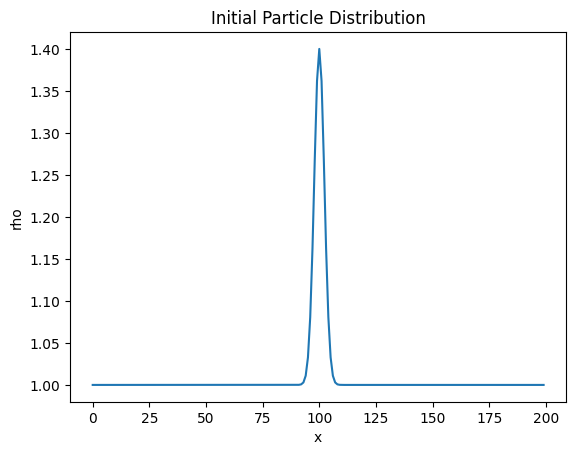

In [29]:
import matplotlib.pyplot as plt

rho = np.sum(F, axis=1)
plt.plot(x, rho)
plt.title("Initial Particle Distribution")
plt.xlabel("x")
plt.ylabel("rho")
plt.show()

In [35]:
plot = plt.figure(figsize=(8, 4)) #opens a figure that is 8 inches wide by 4 inches tall
plt.show()

<Figure size 800x400 with 0 Axes>

In [37]:
N_timesteps = 100

for i in range(N_timesteps):
    F_streamed = np.zeros_like(F) # Create a new array to hold the streamed values after they move - same size and shape as F but filled with zeros
    
    F_streamed[:, 0] = F[:, 0]
    F_streamed[1:, 1] = F[:-1, 1]
    F_streamed[:-1, 2] = F[1:, 2]

    #BOUNCEBACK
    F_streamed[-1, 2] += F[-1, 1] # The particles that were in direction 1 and at the right edge move to direction 2
    F_streamed[0, 1] += F[0, 2] # The particles that were in direction 2 and at the left edge move to direction 1   

    F = F_streamed # Update F to be the streamed version for the next iteration

    rho = np.sum(F, axis=1) # Calculate the density by summing over the directions for each position
    u = np.sum(F * c_x, axis=1) / rho # Calculate the velocity by taking the weighted sum of the directions and dividing by density



\begin{equation}
    u(x) = \frac{F_0c_0 + F_1c_1 + F_2c_2}{\rho}
\end{equation}

\begin{equation}
    c_0 = 0,\ c_1 =1,\ c_2=-1
\end{equation}

\begin{equation}
    u(x) = \frac{F_1-F_2}{\rho}
\end{equation}

So, if:
- $F_1>F_2$, fluid moves to the right
- $F_2>F_1$, fluid moves to the left
- $F_1=F_2$, velocity is zero

##### Equilibrium Formula

\begin{equation}
    F_i^{eq}=\rho w_i(1+3c_iu+4.5(c_iu)^2-1.5u^2)
\end{equation}